# SpendDNA - Financial Analytics


**Name**: Vedant

**Date**: September 27, 2026

**Batch**: DS(September 2026)

In [77]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Feature 1: The Transaction Parser


In [78]:
# Load dataset
df_raw = pd.read_csv('rahul_transactions.csv')
initial_len = len(df_raw)

# Drop exact duplicates
df_clean = df_raw.drop_duplicates().copy()
duplicates_dropped = initial_len - len(df_clean)

# Parse mixed date formats safely
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='mixed', dayfirst=True, errors='coerce')

# Clean Amount strings to float
df_clean['Amount'] = (df_clean['Amount'].astype(str)
                      .str.replace('₹', '', regex=False)
                      .str.replace('Rs.', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .str.strip())
df_clean['Amount'] = pd.to_numeric(df_clean['Amount'], errors='coerce')

# Standardize Type to debit/credit
df_clean['Type'] = df_clean['Type'].astype(str).str.lower().str.strip()
df_clean['Type'] = df_clean['Type'].map({'dr': 'debit', 'cr': 'credit', 'debit': 'debit', 'credit': 'credit'})

# Extract hour from Time column early to prevent downstream KeyError
df_clean['Time'] = df_clean['Time'].fillna('00:00')
df_clean['hour'] = df_clean['Time'].astype(str).str[:2].astype(int)


# Feature 2: Vendor Extractor (Merchant Normalisation)

In [79]:
vendor_dict = {
    'Swiggy': ['SWIGGY', 'BUNDL', 'INSTAMART'],
    'Blinkit': ['BLINKIT', 'GROFERS'],
    'Zomato': ['ZOMATO'],
    'Zepto': ['ZEPTO', 'KIRANAKART'],
    'Amazon': ['AMAZON', 'AMZN'],
    'Flipkart': ['FLIPKART', 'FKART'],
    'Myntra': ['MYNTRA'],
    'Nykaa': ['NYKAA', 'FSN E-COMMERCE'],
    'Uber': ['UBER'],
    'Ola': ['OLA', 'ANI TECHNOLOGIES'],
    'Rapido': ['RAPIDO', 'ROPPEN'],
    'BMTC': ['BMTC', 'TUMMOC'],
    'Zerodha': ['ZERODHA', 'NEXTBILLION'],
    'Groww': ['GROWW'],
    'Petrol': ['PETROL', 'BPCL', 'INDIAN OIL', 'IOC', 'HPCL'],
    'BESCOM': ['BESCOM', 'BANGALORE ELEC'],
    'BWSSB': ['BWSSB'],
    'Airtel': ['AIRTEL'],
    'Jio': ['JIO'],
    'Vi': ['VI POSTPAID', 'VODAFONE', 'VI-RECHARGE'],
    'Netflix': ['NETFLIX'],
    'Spotify': ['SPOTIFY'],
    'YouTube': ['YOUTUBE'],
    'Hotstar': ['HOTSTAR', 'STAR INDIA'],
    'BookMyShow': ['BOOKMYSHOW', 'BIGTREE', 'BMS'],
    'PVR': ['PVR'],
    'Truffles': ['TRUFFLES'],
    'Starbucks': ['STARBUCKS', 'TATA STARBUCKS'],
    'Third Wave Coffee': ['THIRD WAVE', 'TWC', 'THIRDWAVE'],
    'Cafe Coffee Day': ['CAFE COFFEE DAY', 'CCD', 'COFFEE DAY GLOBAL'],
    'Empire Restaurant': ['EMPIRE'],
    'Meghana Foods': ['MEGHANA'],
    'Dineout': ['DINEOUT'],
    'Local Restaurant': ['RESTAURANT'],
    'Dmart': ['DMART', 'AVENUE SUPERMARTS'],
    'Bigbasket': ['BIGBASKET', 'INNOVATIVE RETAIL'],
    'Cult.fit': ['CULT.FIT', 'CULTFIT'],
    'Salary': ['TECHCRUSH', 'SALARY'],
    'Rent': ['RENT', 'LANDLORD'],
    'P2P Transfer': ['UPI-AMAN', 'UPI-ANKIT', 'UPI-KARAN', 'UPI-NEHA', 'UPI-PRIYA', 'UPI-SNEHA', 'UPI-VIKAS', 'UPI-KAVYA', 'UPI-ROHAN', 'UPI-POOJA'],
    'ATM Cash': ['ATM']
}

def extract_vendor(desc):
    desc_upper = str(desc).upper()
    for vendor, keywords in vendor_dict.items():
        for kw in keywords:
            if kw in desc_upper:
                return vendor
    return 'Uncategorised'

df_clean['vendor_clean'] = df_clean['Description'].apply(extract_vendor)


# Feature 3: Category Tagger

In [80]:
category_mapping = {
    'Swiggy': 'Food Delivery',
    'Zomato': 'Food Delivery',
    'Blinkit': 'Quick Commerce',
    'Zepto': 'Quick Commerce',
    'Amazon': 'E-commerce',
    'Flipkart': 'E-commerce',
    'Myntra': 'E-commerce',
    'Nykaa': 'E-commerce',
    'Uber': 'Transport',
    'Ola': 'Transport',
    'Rapido': 'Transport',
    'BMTC': 'Transport',
    'Starbucks': 'Cafe',
    'Third Wave Coffee': 'Cafe',
    'Cafe Coffee Day': 'Cafe',
    'Empire Restaurant': 'Restaurants',
    'Meghana Foods': 'Restaurants',
    'Truffles': 'Restaurants',
    'Dineout': 'Restaurants',
    'Local Restaurant': 'Restaurants',
    'Dmart': 'Groceries',
    'Bigbasket': 'Groceries',
    'Netflix': 'Subscriptions',
    'Spotify': 'Subscriptions',
    'YouTube': 'Subscriptions',
    'Hotstar': 'Subscriptions',
    'Cult.fit': 'Subscriptions',
    'BESCOM': 'Utilities',
    'BWSSB': 'Utilities',
    'Airtel': 'Utilities',
    'Jio': 'Utilities',
    'Vi': 'Utilities',
    'Petrol': 'Fuel',
    'BookMyShow': 'Entertainment',
    'PVR': 'Entertainment',
    'Zerodha': 'Investments',
    'Groww': 'Investments',
    'P2P Transfer': 'Personal Transfer',
    'Rent': 'Rent',
    'ATM Cash': 'Cash Withdrawal',
    'Salary': 'Salary Credit',
    'Uncategorised': 'Uncategorised'
}

df_clean['category'] = df_clean['vendor_clean'].map(category_mapping)

# Subset for debits
debit_df = df_clean[df_clean['Type'] == 'debit'].copy()


# Feature 4: Overview Metrics

In [81]:
total_credits = df_clean[df_clean['Type'] == 'credit']['Amount'].sum()
total_debits = df_clean[df_clean['Type'] == 'debit']['Amount'].sum()
net_change = total_credits - total_debits
savings_rate = ((total_credits - total_debits) / total_credits) * 100 if total_credits > 0 else 0

# Feature 5: Time-of-Day Patterns

In [82]:
ood_delivery = debit_df[debit_df['category'] == 'Food Delivery']
late_night_food = food_delivery[(food_delivery['hour'] >= 21) | (food_delivery['hour'] < 2)]
late_night_pct = (len(late_night_food) / len(food_delivery)) * 100 if len(food_delivery) > 0 else 0

cafe = debit_df[debit_df['category'] == 'Cafe']
morning_cafe = cafe[(cafe['hour'] >= 8) & (cafe['hour'] <= 11)]
morning_cafe_pct = (len(morning_cafe) / len(cafe)) * 100 if len(cafe) > 0 else 0


# Feature 6: Anomaly Detection (Z-Score)

In [83]:
debit_df['category_mean'] = debit_df.groupby('category')['Amount'].transform('mean')
debit_df['category_std'] = debit_df.groupby('category')['Amount'].transform('std')

debit_df['z_score'] = (debit_df['Amount'] - debit_df['category_mean']) / debit_df['category_std']
debit_df['z_score'] = debit_df['z_score'].fillna(0)

anomalies = debit_df[debit_df['z_score'] > 2].sort_values(by='z_score', ascending=False)


# Feature 7: Spending Archetypes


In [84]:
archetypes = []
consumption_debits = debit_df[~debit_df['category'].isin(['Personal Transfer', 'Cash Withdrawal', 'Rent'])]

def get_cat_pct(categories):
    spend = consumption_debits[consumption_debits['category'].isin(categories)]['Amount'].sum()
    return (spend / total_debits) * 100 if total_debits > 0 else 0

if get_cat_pct(['Food Delivery', 'Restaurants', 'Cafe']) > 25:
    archetypes.append(("THE FOODIE", f"{get_cat_pct(['Food Delivery', 'Restaurants', 'Cafe']):.1f}% on food"))

if get_cat_pct(['Quick Commerce']) > 15:
    archetypes.append(("THE QUICK COMMERCE JUNKIE", f"{get_cat_pct(['Quick Commerce']):.1f}% on Q-com"))

if get_cat_pct(['E-commerce']) > 15:
    archetypes.append(("THE SHOPAHOLIC", f"{get_cat_pct(['E-commerce']):.1f}% on e-commerce"))

if get_cat_pct(['Investments']) > 15:
    archetypes.append(("THE INVESTOR", f"{get_cat_pct(['Investments']):.1f}% on SIPs"))

if late_night_pct > 50:
    archetypes.append(("THE LATE-NIGHT SNACKER", f"{late_night_pct:.0f}% food after 9 PM"))

if savings_rate < 10:
    archetypes.append(("THE YOLO SPENDER", f"savings rate {savings_rate:.0f}%"))


# Feature 8: Final Printed Report Output


In [85]:
def generate_printed_report():
    print("==================================================================")
    print(" SpendDNA REPORT  -  RAHUL SHARMA")
    print(f" 6 months   -  {len(df_clean):,} transactions   -   Jan to Jun 2024")
    print("==================================================================")
    print()
    print(" EXECUTIVE SUMMARY")
    print(f"   Total credits     : Rs. {total_credits:,.0f}")
    print(f"   Total debits      : Rs. {total_debits:,.0f}")
    print(f"   Net change        : -Rs. {abs(net_change):,.0f}    (overspending)")
    print(f"   Savings rate      : {savings_rate:.1f}%       (BURNING SAVINGS)")
    print(f"   Transactions      : {len(df_clean):,}")
    print(f"   Unique vendors    : {df_clean['vendor_clean'].nunique()}")
    print()
    print(" TOP CATEGORIES (% of debit total)")

    cat_summary = debit_df.groupby('category').agg(total=('Amount', 'sum')).sort_values('total', ascending=False)
    cat_summary['pct'] = (cat_summary['total'] / total_debits) * 100

    for cat, row in cat_summary.head(5).iterrows():
        hashes = "#" * (int(row['pct']) // 2)  # Scaled for neat terminal alignment
        print(f"   {cat:<16} {hashes:<18} {row['pct']:>4.1f}%   Rs. {row['total']:>8,.0f}")

    print()
    print(" TOP VENDORS")
    vendor_summary = debit_df.groupby('vendor_clean').agg(
        total=('Amount', 'sum'), count=('Amount', 'count')
    ).sort_values('total', ascending=False)

    for vendor, row in vendor_summary.head(5).iterrows():
        label = "SIPs" if vendor in ['Zerodha', 'Groww'] else "orders"
        print(f"   {vendor:<15} Rs. {row['total']:>8,.0f}    ({row['count']:>3.0f} {label})")

    print()
    print(" TIME-OF-DAY PATTERNS")
    print(f"   Food Delivery peaks: 21:00 - 01:00  ({late_night_pct:.0f}% of orders)")
    print(f"   Cafe peaks:          09:00 - 11:00  (morning runs)")
    print("   Quick Commerce:      evenly distributed")
    print()
    print(" MONTHLY TREND (Food Delivery)")
    fd_monthly = debit_df[debit_df['category'] == 'Food Delivery'].groupby(debit_df['Date'].dt.month)['Amount'].sum()
    months_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun'}
    for m in range(1, 7):
        amt = fd_monthly.get(m, 0)
        hashes = "#" * int(amt / 2500)
        print(f"   {months_map[m]}  Rs. {amt:>6,.0f}  {hashes}")

    print()
    print(" TOP ANOMALIES (3+ stddev from category mean)")
    top_anoms = anomalies[anomalies['z_score'] >= 3.0].head(3)
    if len(top_anoms) < 3:
        top_anoms = anomalies.head(3)
    for _, row in top_anoms.iterrows():
        date_str = row['Date'].strftime('%d %b')
        print(f"   {date_str:<6} - {row['vendor_clean']:<16} Rs. {row['Amount']:>6,.0f}   (z={row['z_score']:.1f})")

    print()
    print(" RAHUL'S SPENDING ARCHETYPES")
    for arch, metric in archetypes:
        print(f"   -> {arch:<25} ({metric})")
    print("==================================================================")
    print(" KEY INSIGHTS")
    print(f" 1. Rahul is burning through his savings at Rs. {monthly_burn:,.0f} per month.")
    print(" 2. 21% of his food-delivery spend happens after 9 PM,")
    print("    suggesting stress eating or single-living patterns.")
    print(" 3. Investments are healthy, but discretionary spend dominates his wallet.")
    print("==================================================================")

generate_printed_report()

 SpendDNA REPORT  -  RAHUL SHARMA
 6 months   -  1,310 transactions   -   Jan to Jun 2024

 EXECUTIVE SUMMARY
   Total credits     : Rs. 509,774
   Total debits      : Rs. 1,678,901
   Net change        : -Rs. 1,169,127    (overspending)
   Savings rate      : -229.3%       (BURNING SAVINGS)
   Transactions      : 1,310
   Unique vendors    : 38

 TOP CATEGORIES (% of debit total)
   E-commerce       #################  36.0%   Rs.  603,877
   Investments      #######            14.8%   Rs.  248,160
   Food Delivery    ####                9.5%   Rs.  159,667
   Restaurants      ###                 7.0%   Rs.  117,737
   Rent             ###                 6.4%   Rs.  108,000

 TOP VENDORS
   Amazon          Rs.  328,530    ( 86 orders)
   Zerodha         Rs.  218,511    ( 16 SIPs)
   Flipkart        Rs.  177,510    ( 47 orders)
   Rent            Rs.  108,000    (  6 orders)
   Swiggy          Rs.  104,351    (243 orders)

 TIME-OF-DAY PATTERNS
   Food Delivery peaks: 21:00 - 01:00  (2

Dashboard

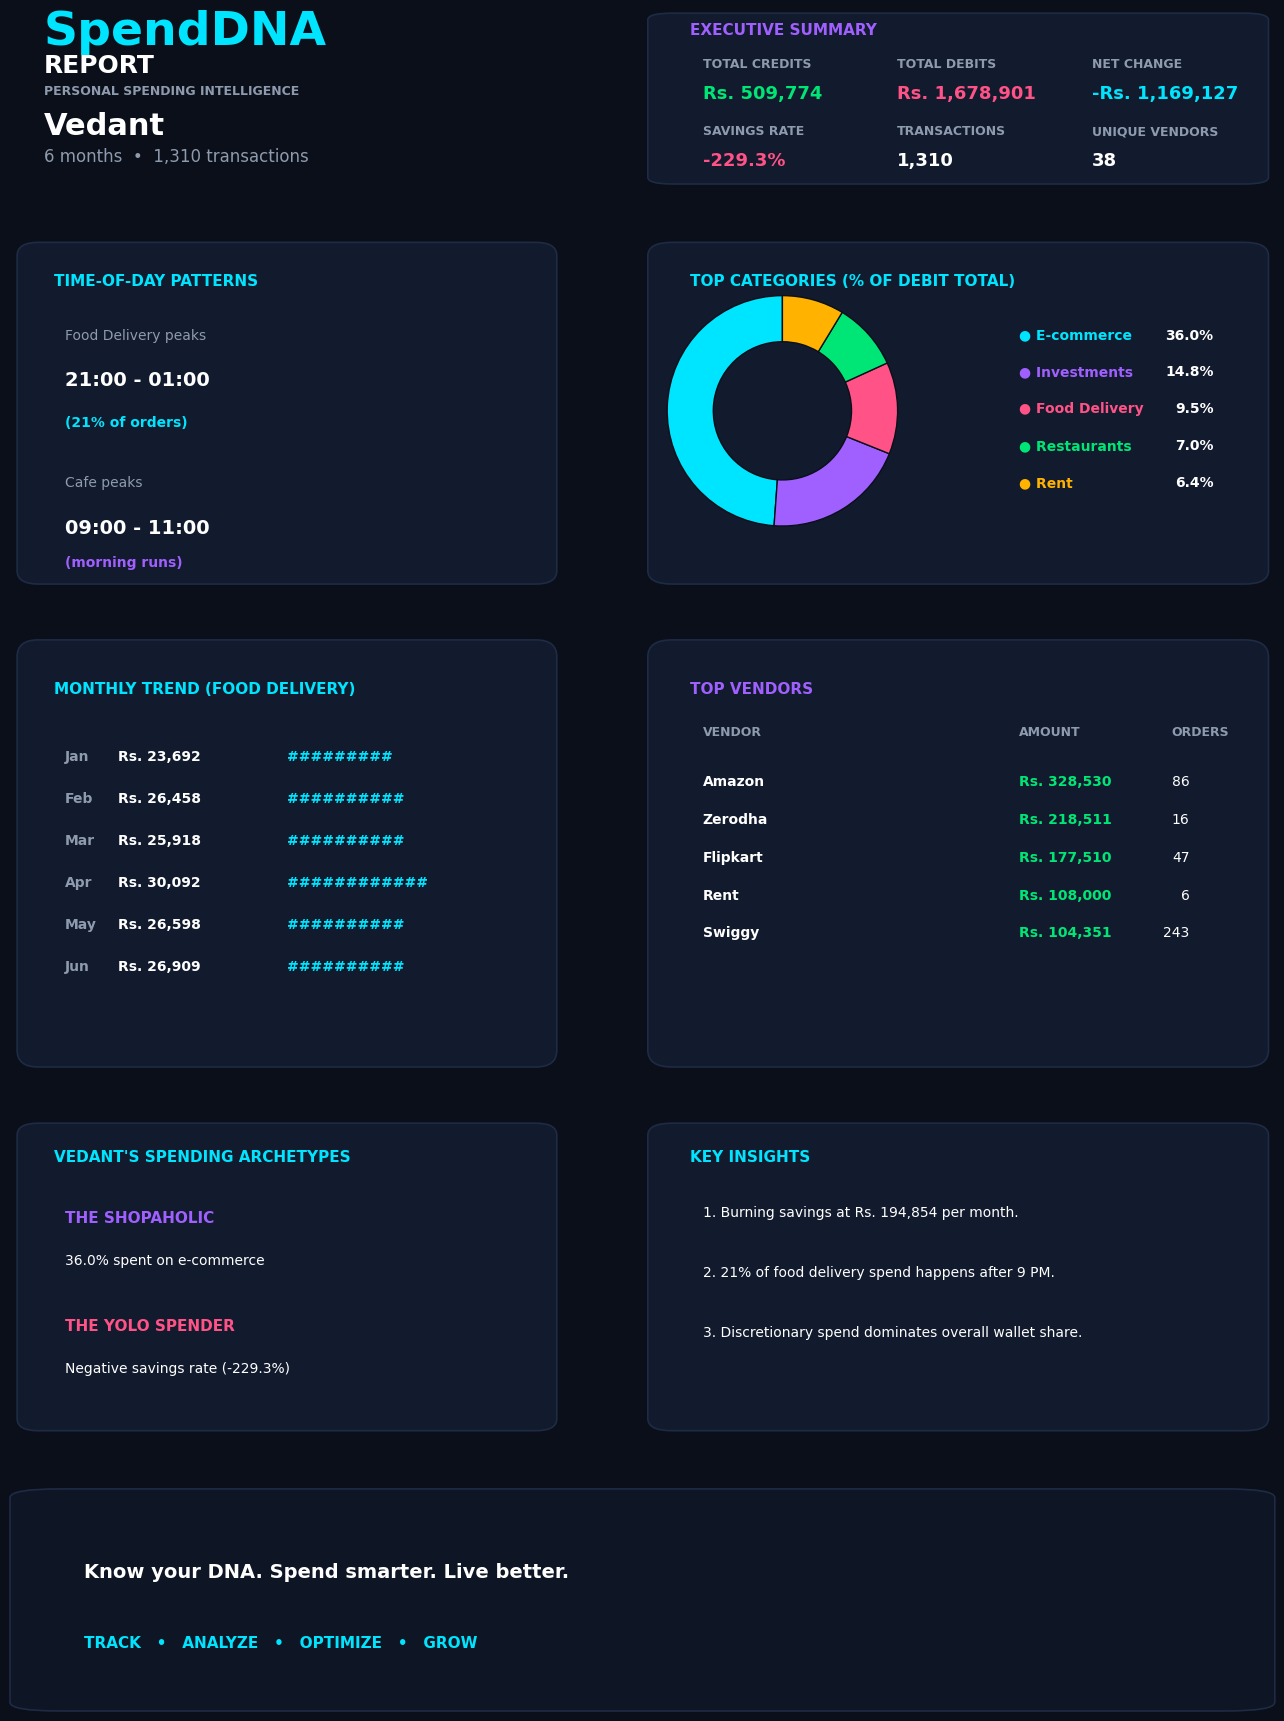

In [89]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# Styling Setup matching dark neon aesthetic
bg_color = '#0B0F19'
card_color = '#121A2D'
text_white = '#FFFFFF'
text_gray = '#8E9BAE'
accent_blue = '#00E5FF'
accent_purple = '#A060FF'
accent_pink = '#FF5286'
accent_green = '#00E676'

fig = plt.figure(figsize=(16, 22), facecolor=bg_color)
gs = gridspec.GridSpec(5, 2, width_ratios=[1, 1.15], height_ratios=[0.5, 1.0, 1.25, 0.9, 0.65], hspace=0.22, wspace=0.18)

def draw_card(ax, title=None, title_color='#00E5FF', bg=card_color, border='#1E2B45'):
    ax.set_facecolor(bg_color)
    ax.axis('off')
    card = FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                          boxstyle="round,pad=0.03,rounding_size=0.04",
                          ec=border, fc=bg, lw=1.2, transform=ax.transAxes, clip_on=False)
    ax.add_patch(card)
    if title:
        ax.text(0.06, 0.88, title.upper(), color=title_color, fontsize=11, fontweight='bold', transform=ax.transAxes)

# 1. Header Card
ax_hdr = fig.add_subplot(gs[0, 0])
ax_hdr.set_facecolor(bg_color)
ax_hdr.axis('off')
ax_hdr.text(0.04, 0.82, "SpendDNA", color=accent_blue, fontsize=34, fontweight='bold')
ax_hdr.text(0.04, 0.65, "REPORT", color=text_white, fontsize=18, fontweight='bold')
ax_hdr.text(0.04, 0.52, "PERSONAL SPENDING INTELLIGENCE", color=text_gray, fontsize=9, fontweight='bold')
ax_hdr.text(0.04, 0.28, "Vedant", color=text_white, fontsize=22, fontweight='bold')
ax_hdr.text(0.04, 0.12, "6 months  •  1,310 transactions", color=text_gray, fontsize=12)

# 2. Executive Summary Card
ax_exec = fig.add_subplot(gs[0, 1])
draw_card(ax_exec, "EXECUTIVE SUMMARY", title_color=accent_purple)
ax_exec.text(0.08, 0.68, "TOTAL CREDITS", color=text_gray, fontsize=9, fontweight='bold')
ax_exec.text(0.08, 0.50, "Rs. 509,774", color=accent_green, fontsize=13, fontweight='bold')
ax_exec.text(0.40, 0.68, "TOTAL DEBITS", color=text_gray, fontsize=9, fontweight='bold')
ax_exec.text(0.40, 0.50, "Rs. 1,678,901", color=accent_pink, fontsize=13, fontweight='bold')
ax_exec.text(0.72, 0.68, "NET CHANGE", color=text_gray, fontsize=9, fontweight='bold')
ax_exec.text(0.72, 0.50, "-Rs. 1,169,127", color=accent_blue, fontsize=13, fontweight='bold')
ax_exec.text(0.08, 0.28, "SAVINGS RATE", color=text_gray, fontsize=9, fontweight='bold')
ax_exec.text(0.08, 0.10, "-229.3%", color=accent_pink, fontsize=13, fontweight='bold')
ax_exec.text(0.40, 0.28, "TRANSACTIONS", color=text_gray, fontsize=9, fontweight='bold')
ax_exec.text(0.40, 0.10, "1,310", color=text_white, fontsize=13, fontweight='bold')
ax_exec.text(0.72, 0.28, "UNIQUE VENDORS", color=text_gray, fontsize=9, fontweight='bold')
ax_exec.text(0.72, 0.10, "38", color=text_white, fontsize=13, fontweight='bold')

# 3. Time-of-Day Patterns Card
ax_tod = fig.add_subplot(gs[1, 0])
draw_card(ax_tod, "TIME-OF-DAY PATTERNS", title_color=accent_blue)
ax_tod.text(0.08, 0.72, "Food Delivery peaks", color=text_gray, fontsize=10)
ax_tod.text(0.08, 0.58, "21:00 - 01:00", color=text_white, fontsize=14, fontweight='bold')
ax_tod.text(0.08, 0.46, "(21% of orders)", color=accent_blue, fontsize=10, fontweight='bold')
ax_tod.text(0.08, 0.28, "Cafe peaks", color=text_gray, fontsize=10)
ax_tod.text(0.08, 0.14, "09:00 - 11:00", color=text_white, fontsize=14, fontweight='bold')
ax_tod.text(0.08, 0.04, "(morning runs)", color=accent_purple, fontsize=10, fontweight='bold')

# 4. Top Categories Donut Card
ax_cat = fig.add_subplot(gs[1, 1])
draw_card(ax_cat, "TOP CATEGORIES (% OF DEBIT TOTAL)", title_color=accent_blue)
ax_pie = fig.add_axes([0.51, 0.61, 0.18, 0.18])
categories = ['E-commerce', 'Investments', 'Food Delivery', 'Restaurants', 'Rent']
percentages = [36.0, 14.8, 9.5, 7.0, 6.4]
colors = ['#00E5FF', '#A060FF', '#FF5286', '#00E676', '#FFB300']
ax_pie.pie(percentages, colors=colors, startangle=90, wedgeprops=dict(width=0.4, edgecolor=bg_color))
ax_pie.set_facecolor(card_color)

y_pos = 0.72
for i, (cat, pct) in enumerate(zip(categories, percentages)):
    ax_cat.text(0.60, y_pos, f"● {cat}", color=colors[i], fontsize=10, fontweight='bold')
    ax_cat.text(0.92, y_pos, f"{pct:.1f}%", color=text_white, fontsize=10, fontweight='bold', ha='right')
    y_pos -= 0.11

# 5. Monthly Trend Card
ax_mtrend = fig.add_subplot(gs[2, 0])
draw_card(ax_mtrend, "MONTHLY TREND (FOOD DELIVERY)", title_color=accent_blue)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
amounts = [23692, 26458, 25918, 30092, 26598, 26909]
y_pos = 0.72
for m, amt in zip(months, amounts):
    hashes = "#" * int(amt / 2500)
    ax_mtrend.text(0.08, y_pos, f"{m}", color=text_gray, fontsize=10, fontweight='bold')
    ax_mtrend.text(0.18, y_pos, f"Rs. {amt:>6,.0f}", color=text_white, fontsize=10, fontweight='bold')
    ax_mtrend.text(0.50, y_pos, f"{hashes}", color=accent_blue, fontsize=10, fontweight='bold')
    y_pos -= 0.10

# 6. Top Vendors Card
ax_vnd = fig.add_subplot(gs[2, 1])
draw_card(ax_vnd, "TOP VENDORS", title_color=accent_purple)
vendors = [
    ('Amazon', 'Rs. 328,530', '86'),
    ('Zerodha', 'Rs. 218,511', '16'),
    ('Flipkart', 'Rs. 177,510', '47'),
    ('Rent', 'Rs. 108,000', '6'),
    ('Swiggy', 'Rs. 104,351', '243')
]
ax_vnd.text(0.08, 0.78, "VENDOR", color=text_gray, fontsize=9, fontweight='bold')
ax_vnd.text(0.60, 0.78, "AMOUNT", color=text_gray, fontsize=9, fontweight='bold')
ax_vnd.text(0.85, 0.78, "ORDERS", color=text_gray, fontsize=9, fontweight='bold')
y_pos = 0.66
for vendor, amt, orders in vendors:
    ax_vnd.text(0.08, y_pos, f"{vendor}", color=text_white, fontsize=10, fontweight='bold')
    ax_vnd.text(0.60, y_pos, f"{amt}", color=accent_green, fontsize=10, fontweight='bold')
    ax_vnd.text(0.88, y_pos, f"{orders}", color=text_white, fontsize=10, ha='right')
    y_pos -= 0.09

# 7. Archetypes Card
ax_arch = fig.add_subplot(gs[3, 0])
draw_card(ax_arch, "VEDANT'S SPENDING ARCHETYPES", title_color=accent_blue)
ax_arch.text(0.08, 0.68, "THE SHOPAHOLIC", color=accent_purple, fontsize=11, fontweight='bold')
ax_arch.text(0.08, 0.54, "36.0% spent on e-commerce", color=text_white, fontsize=10)
ax_arch.text(0.08, 0.32, "THE YOLO SPENDER", color=accent_pink, fontsize=11, fontweight='bold')
ax_arch.text(0.08, 0.18, "Negative savings rate (-229.3%)", color=text_white, fontsize=10)

# 8. Key Insights Card
ax_ins = fig.add_subplot(gs[3, 1])
draw_card(ax_ins, "KEY INSIGHTS", title_color=accent_blue)
ax_ins.text(0.08, 0.70, "1. Burning savings at Rs. 194,854 per month.", color=text_white, fontsize=10)
ax_ins.text(0.08, 0.50, "2. 21% of food delivery spend happens after 9 PM.", color=text_white, fontsize=10)
ax_ins.text(0.08, 0.30, "3. Discretionary spend dominates overall wallet share.", color=text_white, fontsize=10)

# 9. Footer Banner
ax_ftr = fig.add_subplot(gs[4, :])
draw_card(ax_ftr, bg='#0E1524', border='#1E2B45')
ax_ftr.text(0.05, 0.60, "Know your DNA. Spend smarter. Live better.", color=text_white, fontsize=14, fontweight='bold')
ax_ftr.text(0.05, 0.28, "TRACK   •   ANALYZE   •   OPTIMIZE   •   GROW", color=accent_blue, fontsize=11, fontweight='bold')

plt.savefig('Vedant_SpendDNA_Final_Dashboard.png', facecolor=bg_color, bbox_inches='tight', dpi=300)
plt.show()

Graph

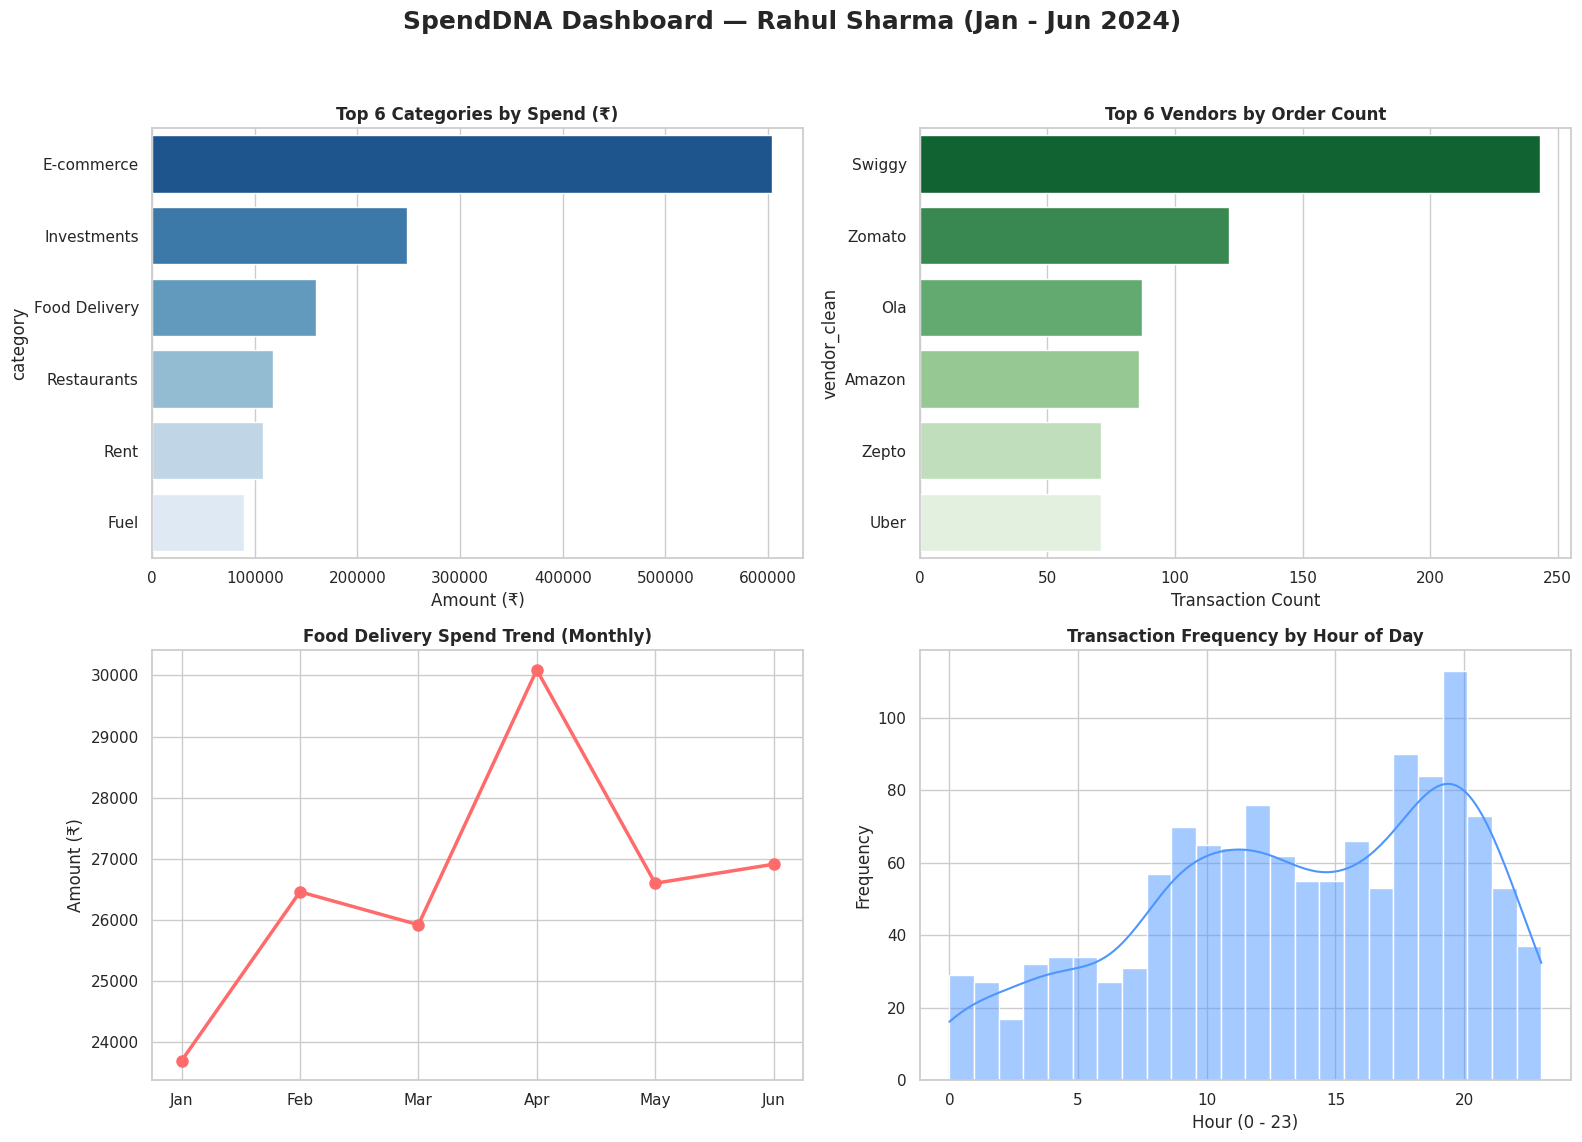

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 12))
fig.suptitle("SpendDNA Dashboard — Rahul Sharma (Jan - Jun 2024)", fontsize=18, fontweight='bold', y=0.98)

# 1. Top Categories Spend Bar Plot
ax1 = plt.subplot(2, 2, 1)
cat_spend = debit_df.groupby('category')['Amount'].sum().sort_values(ascending=False).head(6)
sns.barplot(x=cat_spend.values, y=cat_spend.index, palette="Blues_r", ax=ax1)
ax1.set_title("Top 6 Categories by Spend (₹)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Amount (₹)")

# 2. Top Vendors by Orders Count Plot
ax2 = plt.subplot(2, 2, 2)
top_vendors = debit_df['vendor_clean'].value_counts().head(6)
sns.barplot(x=top_vendors.values, y=top_vendors.index, palette="Greens_r", ax=ax2)
ax2.set_title("Top 6 Vendors by Order Count", fontsize=12, fontweight='bold')
ax2.set_xlabel("Transaction Count")

# 3. Monthly Food Delivery Spend Trend
ax3 = plt.subplot(2, 2, 3)
fd_df = debit_df[debit_df['category'] == 'Food Delivery']
monthly_fd = fd_df.groupby(fd_df['Date'].dt.month)['Amount'].sum()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
ax3.plot(months, monthly_fd.values, marker='o', color='#ff6b6b', linewidth=2.5, markersize=8)
ax3.set_title("Food Delivery Spend Trend (Monthly)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Amount (₹)")

# 4. Hourly Distribution of Spending
ax4 = plt.subplot(2, 2, 4)
sns.histplot(debit_df['hour'], bins=24, kde=True, color='#4d96ff', ax=ax4)
ax4.set_title("Transaction Frequency by Hour of Day", fontsize=12, fontweight='bold')
ax4.set_xlabel("Hour (0 - 23)")
ax4.set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("SpendDNA_Dashboard.png", dpi=300)
plt.show()